In [2]:
%pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 4.2 MB/s eta 0:09:44
     ---------------------------------------- 0.0/2.4 GB 6.9 MB/s eta 0:05:57
     ---------------------------------------- 0.0/2.4 GB 7.1 MB/s eta 0:05:44
     ---------------------------------------- 0.0/2.4 GB 6.8 MB/s eta 0:05:58
     ---------------------------------------- 0.0/2.4 GB 6.7 MB/s eta 0:06:05
     ---------------------------------------- 0.0/2.4 GB 6.8 MB/s eta 0:06:02
     ---------------------------------------- 0.0/2.4 GB 6.5 MB/s eta 0:06:17
     ---------------------------------------- 0.0/2.4 GB 6.5 MB/s eta 0:06:17
     ---------------------------------------- 0.0/2.4 GB 6.5 MB/s eta 0:06:17
     ---------------------------------------- 0.0/2.4 GB 6.5 MB/s eta 0:06:17
     --------------

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [7]:
%pip install opencv-python numpy faiss-cpu facenet-pytorch tqdm


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached facenet_pytorch-2.6.0-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.8/40.2 MB 10.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/40.2 MB 8.4 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/40.2 MB 7.7 MB/s eta 0:00:05
   ----- ---------------------------------- 5.8/40.2 MB 7.3 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/40.2 MB 7.2 MB/s eta 0:00:05
   -------- ------------------------------- 8.7/40.2 MB 7.1 MB/s eta 0:00:05
   --------- ------------------------------ 10.0/40.2 MB 7.0 MB/s eta 0:00:05
   ----------- ------

In [52]:
%pip install matplotlib

from facenet_pytorch import MTCNN
import cv2
import matplotlib.pyplot as plt

mtcnn = MTCNN(keep_all=True)

def extract_faces(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        print("Image not found:", image_path)
        return []

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # THIS does detection + alignment + resizing
    faces = mtcnn(img_rgb)

    if faces is None:
        print("No faces detected")
        return []

    # faces are already tensors (aligned)
    return faces

Note: you may need to restart the kernel to use updated packages.


e:\face\.venv\lib\site-packages\facenet_pytorch\models\mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(state_dict_path)
e:\face\.venv\lib\

In [44]:
extract_faces("me.jpg")

tensor([[[[-0.7852, -0.8086, -0.8398,  ..., -0.8633, -0.8633, -0.8711],
          [-0.8008, -0.8320, -0.8398,  ..., -0.8633, -0.8789, -0.8945],
          [-0.8164, -0.8398, -0.8320,  ..., -0.8477, -0.8633, -0.8789],
          ...,
          [ 0.7852,  0.5898,  0.1992,  ..., -0.3477, -0.1992,  0.1445],
          [ 0.7773,  0.4883, -0.2461,  ..., -0.0742,  0.2070,  0.2539],
          [ 0.7695,  0.6211,  0.2148,  ...,  0.2227,  0.2305,  0.2617]],

         [[-0.7930, -0.8164, -0.8477,  ..., -0.8555, -0.8633, -0.8789],
          [-0.8086, -0.8398, -0.8477,  ..., -0.8555, -0.8711, -0.9023],
          [-0.8242, -0.8477, -0.8398,  ..., -0.8398, -0.8555, -0.8867],
          ...,
          [ 0.7461,  0.5195,  0.1211,  ..., -0.4883, -0.3477, -0.0117],
          [ 0.7383,  0.4414, -0.3008,  ..., -0.2227,  0.0508,  0.0898],
          [ 0.7305,  0.5820,  0.1836,  ...,  0.0664,  0.0664,  0.0977]],

         [[-0.8242, -0.8477, -0.8789,  ..., -0.9102, -0.9023, -0.9102],
          [-0.8398, -0.8711, -

In [45]:
from facenet_pytorch import InceptionResnetV1
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_embedding(face_tensor):
    face_tensor = face_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(face_tensor)

    return emb.cpu().numpy()[0]

e:\face\.venv\lib\site-packages\facenet_pytorch\models\inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.99609375].


Total faces in group: 9

Face 1 similarity: 0.0149


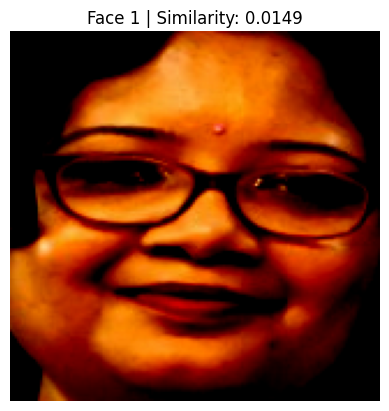

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.99609375].


Face 2 similarity: 0.6470


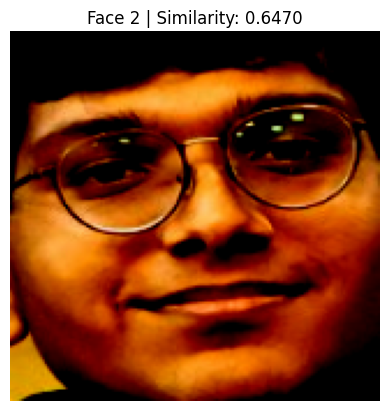

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.99609375].


Face 3 similarity: 0.0561


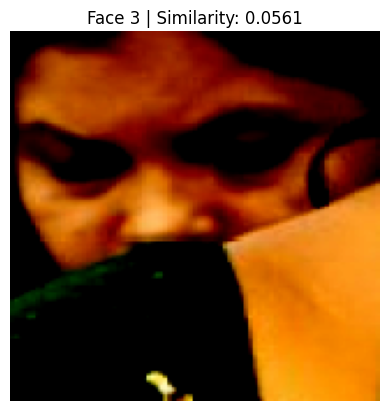

Face 4 similarity: -0.0535

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83984375..0.99609375].


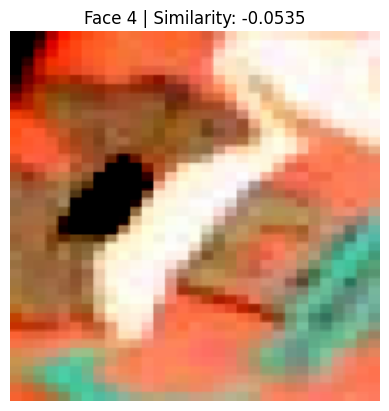

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.86328125..0.23828125].


Face 5 similarity: 0.0734


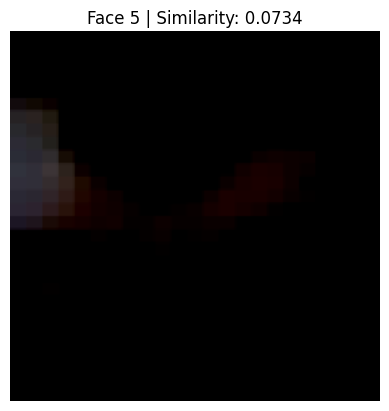

Face 6 similarity: -0.2117


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94921875..0.80078125].


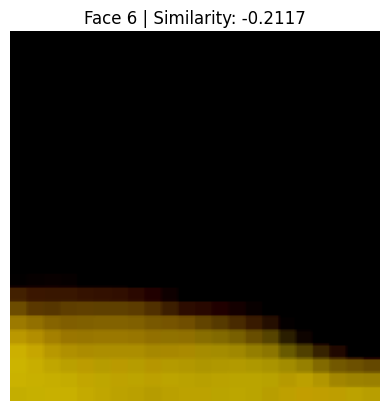

Face 7 similarity: 0.0035


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76171875..-0.16015625].


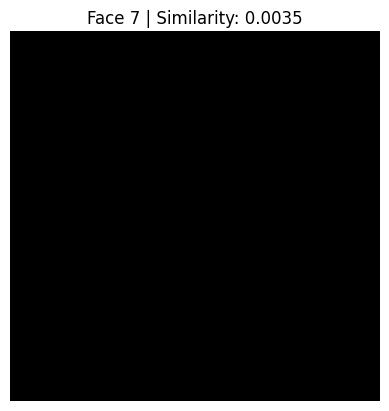

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83203125..0.33984375].


Face 8 similarity: -0.1920


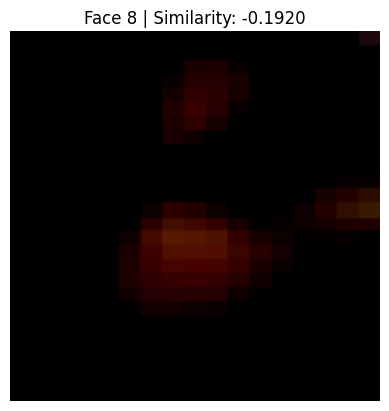

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93359375..0.99609375].


Face 9 similarity: -0.2054


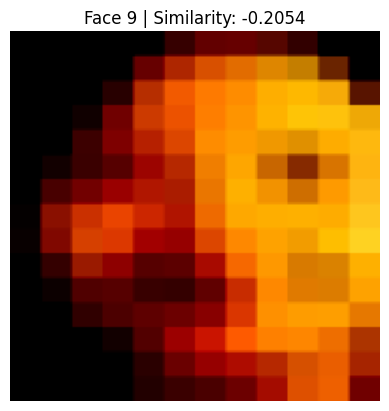

In [ ]:
from facenet_pytorch import MTCNN, InceptionResnetV1
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# models
mtcnn = MTCNN(keep_all=True, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)


# ---------- FACE EXTRACTION ----------
def extract_faces(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Image not found:", image_path)
        return []

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = mtcnn(img_rgb)

    if faces is None:
        print("No faces detected")
        return []

    return faces


# ---------- EMBEDDING ----------
def get_embedding(face_tensor):
    face_tensor = face_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(face_tensor)

    return emb.cpu().numpy()[0]


# ---------- SIMILARITY ----------
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# ---------- TEST ----------
query_faces = extract_faces("me.jpg")
group_faces = extract_faces("me3.jpeg")

query_emb = get_embedding(query_faces[0])

print(f"Total faces in group: {len(group_faces)}\n")

for i, face in enumerate(group_faces):
    emb = get_embedding(face)
    sim = cosine_similarity(query_emb, emb)

    print(f"Face {i+1} similarity: {sim:.4f}")

    # show face
    face_np = face.permute(1, 2, 0).cpu().numpy()
    plt.imshow(face_np)
    plt.title(f"Face {i+1} | Similarity: {sim:.4f}")
    plt.axis('off')
    plt.show()

In [62]:
import os

def find_person_in_folder(query_img, folder_path, threshold=0.6):
    matches = set()

    query_faces = extract_faces(query_img)

    if len(query_faces) == 0:
        print("No face in query image")
        return []

    query_emb = get_embedding(query_faces[0])

    for img_name in os.listdir(folder_path):
        path = os.path.join(folder_path, img_name)

        faces = extract_faces(path)

        for face in faces:
            emb = get_embedding(face)
            sim = cosine_similarity(query_emb, emb)

            if sim >= threshold:
                matches.add(path)
                break  # stop checking more faces in this image

    return list(matches)

Matched Images: 4


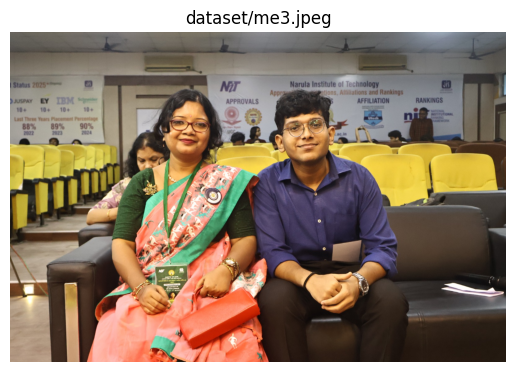

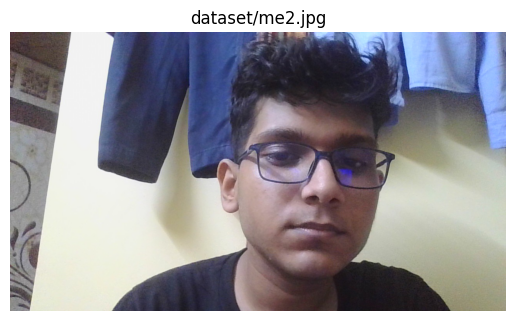

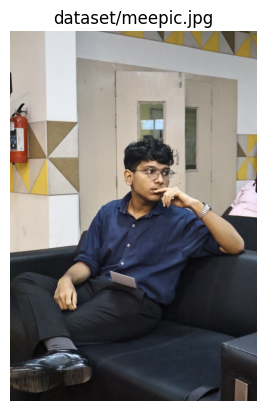

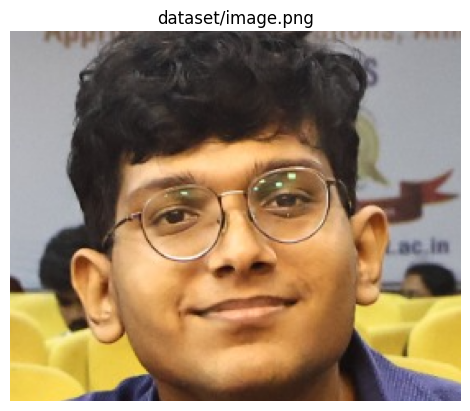

In [64]:
results = find_person_in_folder("me.jpg", "dataset/")

import matplotlib.pyplot as plt
import cv2

print("Matched Images:", len(results))

for path in results:
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(path)
    plt.axis('off')
    plt.show()